In [1]:
from matplotlib import pyplot as plt
import seaborn as sns
import json
import tqdm

import numpy as np
import pandas as pd

#from bleurt import score


In [117]:
datasets: dict = {}  # Dictionary to hold per-model DataFrames

baseline_file =     ('evaluation_translations/smolsent_test_translations_original_madlad.json')  # Baseline file path
token_swap_file =   ('evaluation_translations/smolsent_test_tokenswap_translations_original_madlad.json')  # Token replacement file path
finetuned_file =    ('evaluation_translations/smolsent_test_translations_finetuned_madlad.json')  # Fine-tuned model file path
ts_finetuned_file = ('evaluation_translations/smolsent_test_tokenswap_translations_finetuned_madlad.json')  # Fine-tuned token replacement file path
file_paths = {
    'Baseline': baseline_file,
    'Token Swap': token_swap_file,
    'Fine-tuned': finetuned_file,
    'TS Fine-tuned': ts_finetuned_file
}

# Read each file and keep only src, trg and the model's translation as a column named by the label
translation_key = 'madlad_translation'
for label, file_path in file_paths.items():
    with open(file_path, 'r') as f:
        data = json.load(f)
        df = pd.DataFrame(data)
        # find translation column (fallback to any column containing 'trans')
        trans_col = translation_key if translation_key in df.columns else next((c for c in df.columns if 'trans' in c.lower()), None)
        if trans_col is None:
            raise KeyError(f"No translation column found in {file_path}")
        df = df[['src', 'trg', trans_col]].rename(columns={trans_col: label})
        trg_label = 'trg' if 'swap' not in file_path.lower() else 'trg_swapped'
        df: pd.DataFrame = df.rename(columns={'trg': trg_label})
        print(df.columns)
        datasets[label] = df

# Merge all model DataFrames on src and trg so each row has translations from every model
from functools import reduce
merged_swapped_df = pd.merge(datasets['Token Swap'], datasets['TS Fine-tuned'], on=['src', 'trg_swapped'], how='outer')
merged_org_df = pd.merge(datasets['Baseline'], datasets['Fine-tuned'], on=['src', 'trg'], how='outer')
merged_df = pd.merge(merged_org_df, merged_swapped_df, on=['src'], how='outer')
# Remove duplicate source sentences (if any) and reset index
merged_df = merged_df.drop_duplicates(subset=['src']).reset_index(drop=True)
# Display the first few rows of the merged (wide) DataFrame
merged_df.head(100)

Index(['src', 'trg', 'Baseline'], dtype='object')
Index(['src', 'trg_swapped', 'Token Swap'], dtype='object')
Index(['src', 'trg', 'Fine-tuned'], dtype='object')
Index(['src', 'trg_swapped', 'TS Fine-tuned'], dtype='object')


,src,trg,Baseline,Fine-tuned,trg_swapped,Token Swap,TS Fine-tuned
0,A warehouse worker in a retail store is holding a cell phone and preparing to package up a parcel to ship overseas.,間零售店嘅倉務員拎住部手機，同埋準備打包個包裹寄去海外。,The storekeeper in the retail store takes the cell phone and prepares to pack a parcel to be sent abroad.,The warehouse clerk at a retail store is holding a cell phone and preparing to pack a package for shipment abroad.,間零售店的倉務員拎居住部手機，和埋準備打包那个包裹寄去海外。,The warehouseman at the retail store took the mobile phone from the residence and prepared to pack the parcel for shipment abroad.,The warehouse clerk at a retail store is carrying a cell phone and preparing to pack the package for shipment abroad.
1,Accessories lend visual appeal through pattern and texture.,配飾通過圖案同質感令視覺外觀更吸引。,The decorations are made more attractive by the uniformity of the pattern.,Decoration makes the visual appearance more appealing by creating a pattern and texture sense.,配飾通过图案和質感令视觉外觀更吸引。,Decoration makes the visual appearance more attractive through patterns and textures.,Decoration adds visual appeal to a space through patterns and textures.
2,"Adaptability - flexible, agile mindset, optimistic approach;",適應能力 - 彈性同靈活嘅思維，積極樂觀嘅態度；,"Adaptability - flexibility and agility of thinking, positive optimism;","Adaptation - resilience and agile thinking, positive optimism;",适应能力 - 弹性和靈活的思維，積極乐观的态度；,"Adaptability - resilience and flexibility of mind, positive optimism;","Adaptation - resilient and flexible thinking, positive optimism;"
3,"As a reminder, this company launched a 34-inch curved gaming monitor last October.",提醒返，呢間公司舊年十月推出咗一款34吋曲面遊戲顯示器。,"In October 2011, the company announced a 34-inch curved gaming monitor.",Recall that the company launched a 34-inch curved gaming monitor last October.,提醒返，呢間公司舊年十月推出咗一款34吋曲脸游戏顯示器。,"In October 2011, the company launched a 34-inch curved-face gaming monitor.",Recall that the company launched a 34-inch curved gaming monitor last October.
4,"As a result, the teeth eventually develop a dull, lackluster appearance.",結果，啲牙最終會變到暗啞無光。,"As a result, the teeth eventually become dull and unsightly.","As a result, the teeth eventually become dull and dim.",结果，啲牙最終会變到暗啞無亮。,"As a result, the teeth eventually become dull and unsightly.","As a result, the teeth eventually become dull and unsightly."
...,...,...,...,...,...,...,...
82,"We might be inspired by books, concepts, or historical figures.",我哋可能會受到書本、概念或者歷史人物嘅啟發。,"We may be inspired by books, concepts, or historical figures.","We may be inspired by books, concepts, or historical figures.",我哋可能会受到书本、概念或者历史人物的啟發。,"We may be inspired by books, concepts or historical figures.","We may be inspired by books, concepts, or historical figures."
83,We will most likely see an extension of the current lockdown while our government ramps up the vaccination efforts.,我哋好大機會會延長現時嘅封鎖措施，同時我哋嘅政府正加快緊疫苗接種嘅工作。,"We are likely to extend the current lockdowns, while our government is accelerating vaccination efforts.","We are likely to extend our current lockdown measures, and our government is accelerating its vaccination drive.",我哋好大机会会延长現時的封锁措施，和時我哋的政府正加快紧疫苗接種的工作。,"We have a good chance of extending the current lockdowns, and our government is accelerating its efforts to tighten vaccination.",We are likely to extend our current lockdown measures as our government accelerates its vaccination drive.
84,"With the advent of sophisticated surveillance and technological innovation, a level of caution must be exercised.",隨住先進嘅監控同創新科技嘅出現，一定要謹慎行事。,The emergence of advanced monitoring and innovative technology requires caution.,"With the advent of advanced monitoring and innovative technologies, it is important to be careful.",隨居住先进的監控和创新科技的出现，一定要謹慎走事。,"With the emergence of advanced monitoring and innovative technology, it is necessary to be careful.","With the advent of advanced monitoring and innovative technologies, it is important to be careful."
85,Withdrawal effects are small and more annoy

In [20]:
scorer = score.BleurtScorer("BLEURT-20")
import tensorflow as tf

INFO:tensorflow:Reading checkpoint BLEURT-20.
INFO:tensorflow:Config file found, reading.
INFO:tensorflow:Will load checkpoint BLEURT-20
INFO:tensorflow:Loads full paths and checks that files exists.
INFO:tensorflow:... name:BLEURT-20
INFO:tensorflow:... bert_config_file:bert_config.json
INFO:tensorflow:... max_seq_length:512
INFO:tensorflow:... vocab_file:None
INFO:tensorflow:... do_lower_case:None
INFO:tensorflow:... sp_model:sent_piece
INFO:tensorflow:... dynamic_seq_length:True
INFO:tensorflow:Creating BLEURT scorer.
INFO:tensorflow:Creating SentencePiece tokenizer.
INFO:tensorflow:Creating SentencePiece tokenizer.
INFO:tensorflow:Will load model: BLEURT-20/sent_piece.model.
INFO:tensorflow:SentencePiece tokenizer created.
INFO:tensorflow:Creating Eager Mode predictor.
INFO:tensorflow:Loading model.


I0000 00:00:1766067356.357263   44881 gpu_device.cc:2421] Ignoring visible gpu device (device: 0, name: AMD Radeon Graphics, pci bus id: 0000:04:00.0) with AMDGPU version : gfx1152. The supported AMDGPU versions are gfx900, gfx906, gfx908, gfx90a, gfx942, gfx950, gfx1030, gfx1100, gfx1101, gfx1103, gfx1150, gfx1151, gfx1200, gfx1201.


INFO:tensorflow:BLEURT initialized.


INFO:tensorflow:BLEURT initialized.


In [5]:
print(tf.version.VERSION)
print(tf.config.list_physical_devices(None))

2.21.0-dev0+selfbuilt
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [6]:
for col in tqdm.tqdm(['Baseline', 'Fine-tuned', 'Token Swap', 'TS Fine-tuned']):
    print(f"Scoring column: {col}")
    references = (merged_df['src'].tolist())
    candidates = merged_df[col].tolist()
    print(references[0])
    scores = scorer.score(references=references, candidates=candidates)
    merged_df[f'{col}_BLEURT'] = scores

  0%|          | 0/4 [00:00<?, ?it/s]

Scoring column: Baseline
A warehouse worker in a retail store is holding a cell phone and preparing to package up a parcel to ship overseas.


 25%|██▌       | 1/4 [03:24<10:14, 204.93s/it]

Scoring column: Fine-tuned
A warehouse worker in a retail store is holding a cell phone and preparing to package up a parcel to ship overseas.


 50%|█████     | 2/4 [06:50<06:50, 205.28s/it]

Scoring column: Token Swap
A warehouse worker in a retail store is holding a cell phone and preparing to package up a parcel to ship overseas.


 75%|███████▌  | 3/4 [10:14<03:24, 204.60s/it]

Scoring column: TS Fine-tuned
A warehouse worker in a retail store is holding a cell phone and preparing to package up a parcel to ship overseas.


100%|██████████| 4/4 [13:37<00:00, 204.33s/it]


In [8]:
#save to csv
merged_df.to_csv('evaluation_translations/combined_smolsent_bleurt_scores_madlad.csv', index=False)

In [22]:
print(f"Baseline:\t\t\t {np.mean(merged_df['Baseline_BLEURT'])}")
print(f"Token swap:\t\t {np.mean(merged_df['Token Swap_BLEURT'])}")
print(f"Fine-tuned:\t\t {np.mean(merged_df['Fine-tuned_BLEURT'])}")
print(f"TS Fine-tuned:\t {np.mean(merged_df['TS Fine-tuned_BLEURT'])}")

Baseline:			 0.6806566989284822
Token swap:		 0.6704189777374268
Fine-tuned:		 0.7254119131756925
TS Fine-tuned:	 0.7144110394620348


In [164]:
merged_df = pd.read_csv('evaluation_translations/combined_smolsent_bleurt_scores_madlad.csv')

In [162]:
with open("unlabelled/token_swap_count.json", "r") as f:
    token_swap_count = json.load(f)
pd.DataFrame.from_records(token_swap_count)

,src,trg,swp,swapped_count
0,Davis wasn’t a passive observer who merely said goodbye to a dying relative;,戴維斯唔係一個只係想同彌留嘅親人道別嘅被動旁觀者；,戴維斯不是一那个只是想和彌留的親人道別的被動旁觀者；,9
1,"Rohan was my sibling who always flew a kite at noon, even if it was cloudy.",羅漢係我兄弟，佢成日喺正午放風箏，就算天陰陰。,羅漢是我兄弟，他成日在正午放风箏，就算天空陰陰。,6
2,"Peace brings along its buddies joy, strength, hope, and faith.",和平會同時帶嚟喜悅、力量、希望同埋信念。,和平会和時帶嚟喜悅、力量、希望和埋信念。,3
3,"However, despite these factors, there was never any regret or desire to quit.",不過，即使有呢啲因素，都從來無後悔過或者想放棄。,不过，即使有这些因素，都从來無后悔過或者想放棄。,7
4,Latest Snapchat caption maker to imitate fake snaps of celebrities and prank your friends.,最新嘅Snapchat字幕製造器，可以模仿名人嘅假快拍嚟整蠱你嘅朋友。,最新的Snapchat字幕制造器，可以模仿名人的假快拍嚟恶作剧你的朋友。,9
...,...,...,...,...
82,Struggle is required in each field of work to achieve success.,每一個行業都要努力奮鬥先可以獲得成功。,每一那个走業都要努力奋斗先可以获得成功。,7
83,"Common side effects of Flecainide include headaches, dizziness, upset stomach, and feeling tired or weak.",氟卡尼嘅常見副作用包括頭痛、頭暈、胃部不適同埋覺得疲倦或者虛弱。,氟卡尼的常见副作用包括头痛、头暈、胃部不適和埋覺行疲倦或者虛弱。,7
84,St. John’s wort is a remedy for seizures and is good for liver health.,聖約翰草係治療癲癇症嘅藥材，亦有益肝臟健康。,聖約翰草是治療疯癇症的药材，亦有益肝臟健康。,4
85,"Jesus is our heaven-sent, born-in-a-stable prophet, priest, and king.",耶穌係我哋從天而降、喺馬槽中出世嘅先知、祭司同埋王。,耶穌是我哋从天空而降、在马槽中出生的先知、祭司和埋王。,10


In [165]:
merged_df['canto_only_chars'] = pd.DataFrame.from_records(token_swap_count)['swapped_count']
merged_df['total_chars'] = merged_df['src'].str.len()
merged_df['canto_char_ratio'] = merged_df['canto_only_chars'] / merged_df['total_chars']

In [166]:
merged_df.sort_values(by='canto_only_chars', ascending=False).head(10)[['src', 'canto_only_chars', 'total_chars', 'canto_char_ratio']]

,src,canto_only_chars,total_chars,canto_char_ratio
23,Gandhi also believed rural economy based mass movement follow non-violent methods.,20,82,0.243902
16,"Divide the sliced steak, roasted potato, and cooked snap peas between two plates.",18,81,0.222222
34,It won’t do to have the fox steal a goose and a duck and celebrate the feast.,17,77,0.220779
72,The smallness of my cry was in comparison like the whisper of a ghost.,16,70,0.228571
76,"These trackers detect motion while you’re lying down to figure out when you’re awake, lightly asleep, or in deep sleep.",15,119,0.126050
9,"Beauty became her mystery, companion, guide, and inspiration.",14,61,0.229508
31,"It has operations in southern, central, and northern Louisiana.",14,63,0.222222
46,Performing minor diagnostic tests and procedures as directed by healthcare professionals.,14,89,0.157303
30,"Incredible detail, fantastic expression, and creative execution combine to form exhibit-worthy creations.",13,105,0.123810
56,"Sometimes they went to bed together, straight away, nothing said.",13,65,0.200000


<Axes: >

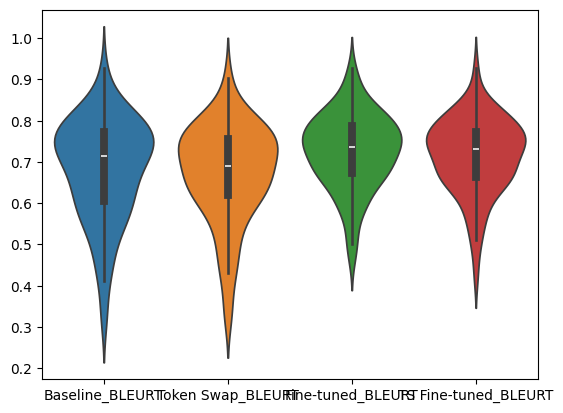

In [167]:
sns.violinplot(data=merged_df[['Baseline_BLEURT', 'Token Swap_BLEURT', 'Fine-tuned_BLEURT', 'TS Fine-tuned_BLEURT']])

In [129]:
merged_df.nsmallest(10, 'Baseline_BLEURT')[['src', 'Baseline', 'Token Swap', 'Fine-tuned', 'TS Fine-tuned']]

,src,Baseline,Token Swap,Fine-tuned,TS Fine-tuned
51,"Rohan was my sibling who always flew a kite at noon, even if it was cloudy.","The bridge is opened to the public at noon, and closed at midnight.","Rohan is my brother, and he flies kites at noon every day, even when the sky is dark.","Rohan is my brother, and he always flies kites at noon, even in the dark.","Rohan is my brother, and he always flies kites at noon, even when the sky is shady."
50,"Rita delighted in the fresh grapes, although she looked more like she had swallowed a watermelon.","He is happy to stay with the freshly-cuts, but he looks more like a watermelon when he falls.","He is happy to live with the fresh watermelon, but he looks more like he swallowed the watermelon.","Vida was happy with the fresh fruit, but she looked more like she had swallowed the watermelon.","Vida was happy to live with the fresh ones, but he looked more like he had swallowed the watermelon."
7,"Basically he's dizzy, can hardly walk, lost his balance, speech was impaired, said spectacular things.","He is a very shy, unconcerned, and unconcerned person, and he is very uncomfortable with the way things are.","He is a very shy person, and he is not very good at talking, but he is very good at talking, and he is very good at talking.","Basically, he was dizzy, he had trouble walking, he couldn't keep his balance, he was talking old-fashioned things, he was talking in a way that wasn't proper.","Basically, he was dizzy, he had trouble walking, he couldn't keep his balance, he was talking like he was a stupid idiot."
25,"Hey guys, sorry for not writing the report, I didn't get home until now after the practice.","I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry...","Hey, guys, I'm sorry I didn't write that report, I've been practicing until I get home.","Hey guys, I'm sorry I can't write this report, I'm just working on it until I get home.","Hey guys, sorry for not writing that report, I've been practicing until I get home."
21,From 10 feet away you could tell the bottom of the boat was in rough shape;,It was very bad from 10 feet away.,The bottom was in poor condition and visible from a distance of 10 feet;,The bottom of the boat was visible from a distance of 10 feet and was in a poor condition;,"The bottom of the boat was in poor condition, visible from 10 feet away;"
86,"You quickly dispatch three of the slowed humanoids with your bolts, their clumsy movements offering little sport.","You quickly shoot back with arrows the three slowly swallowing puppets, and they are not challenging at all.","The three men are then forced to fight back against the three other men, who are not able to resist the force.","You quickly shoot back with your arrows at the three slow-eating antropomorphs, who seem to be no challenge at all.","You quickly shoot back with your arrows at the three slow-eating humanoids, who seem to be no challenge at all."
61,Superior grip and slip-resistance thanks to surface patterns and large contact area.,"The surface of the blade is smooth and smooth, with a good grip and a good grip.",The texture of the multi-row surface and the large contact volume make the hand feel good and non-slip.,The added texture and large contact area of the surface makes it feel good in the hand and not slip.,The texture of the multi-layer surface and the large contact area make it feel good in the hand and not slip.
9,"Beauty became her mystery, companion, guide, and inspiration.","She became his secret, companion, mentor and inspiration.","He became his mentor, mentor, and mentor.","Beauty became her secret, her companion, her mentor, and her inspiration.","Beauty became his secret, his companion, his mentor, and his inspiration."
19,"Fly balls flew by as I landed on my face, spit weed stalks and hoped to disappear in humiliation.","When I fell 

In [168]:
merged_df['diff_Base_to_TS'] =    merged_df['Token Swap_BLEURT']    - merged_df['Baseline_BLEURT']
merged_df['diff_Base_to_FT'] =    merged_df['Fine-tuned_BLEURT']    - merged_df['Baseline_BLEURT']
merged_df['diff_Base_to_TSFT'] =  merged_df['TS Fine-tuned_BLEURT'] - merged_df['Baseline_BLEURT']
merged_df['diff_FT_to_TSFT'] =   merged_df['TS Fine-tuned_BLEURT'] - merged_df['Fine-tuned_BLEURT']

In [131]:
merged_df[merged_df['src'].str.contains('report')]

,src,trg,Baseline,Fine-tuned,trg_swapped,Token Swap,TS Fine-tuned,Baseline_BLEURT,Fine-tuned_BLEURT,Token Swap_BLEURT,TS Fine-tuned_BLEURT,canto_only_chars,total_chars,canto_char_ratio,diff_Base_to_TS,diff_Base_to_FT,diff_Base_to_TSFT,diff_FT_to_TSFT
25,"Hey guys, sorry for not writing the report, I didn't get home until now after the practice.",喂各位，對唔住無寫到個報告，我一直練習到依家先返到屋企。,"I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry...","Hey guys, I'm sorry I can't write this report, I'm just working on it until I get home.",嘿各位，对不起無写到那个报告，我一直练习到依家先返到家。,"Hey, guys, I'm sorry I didn't write that report, I've been practicing until I get home.","Hey guys, sorry for not writing that report, I've been practicing until I get home.",0.422124,0.601395,0.648426,0.645264,1,28,0.035714,0.226302,0.179271,0.223140,0.043868
60,"Substandard identification, recording, and reporting procedures.",辨識、記錄同報告程序質量唔達標。,"The quality of the identification, recording and reporting procedures is not satisfactory.","Identification, recording, and reporting processes are not up to standard.",辨識、記錄和报告程序質量不達標。,"The quality of the procedures for identifying, recording and reporting was not satisfactory.","Identification, recording and reporting processes were not up to standard.",0.773754,0.799382,0.754630,0.770251,1,16,0.062500,-0.019124,0.025628,-0.003504,-0.029131


In [198]:
pd.options.display.max_colwidth = 200
merged_df.sort_values(by='diff_Base_to_TS', ascending=True).head(10)[['src', 'Baseline', 'Token Swap', 'diff_Base_to_TS']]

,src,Baseline,Token Swap,diff_Base_to_TS
32,"It includes a legend of a devil beast, a century-old family curse.","It includes a legendary demon beast, a family curse that has lasted for hundreds of years.",He is the one who has been the master of the witchcraft for centuries.,-0.379743
8,"Bear in mind, constantly try to purchase silk plants, as they tend to appear like the genuine thing.","Remember, keep trying to buy silk plants because they look like real ones.",They are often used to make the plant's leaves and flowers look like they are actually flowers.,-0.291243
14,Connected couples grow closer through having shared and separate interests.,Having both common and independent interests will make the couple closer.,The interest in republic and independence will make the couple more intimate.,-0.276219
59,Struggle is required in each field of work to achieve success.,Every industry has to work hard to succeed.,Everyone who goes to work to fight first to succeed.,-0.224063
35,Its designation as a competitive organization means that it faces a lot of competition.,"It is a competitive organization, meaning it faces a lot of competition.","He was positioned as one of the competitive organizations, meaning that living there meant facing a lot of competition.",-0.198096
31,"It has operations in southern, central, and northern Louisiana.","It operates in southern, central and northern Louisiana.","He operated in southern, central, and northern Louisiana.",-0.167823
17,"Even if a review gave the film a poor score, most praise the opening chase sequence.","Although the film received mixed reviews, most critics praised its opening scene.","Although the film received mixed reviews, most critics praised the performance of the cast.",-0.160837
9,"Beauty became her mystery, companion, guide, and inspiration.","She became his secret, companion, mentor and inspiration.","He became his mentor, mentor, and mentor.",-0.159886
86,"You quickly dispatch three of the slowed humanoids with your bolts, their clumsy movements offering little sport.","You quickly shoot back with arrows the three slowly swallowing puppets, and they are not challenging at all.","The three men are then forced to fight back against the three other men, who are not able to resist the force.",-0.137258
0,A warehouse worker in a retail store is holding a cell phone and preparing to package up a parcel to ship overseas.,The storekeeper in the retail store takes the cell phone and prepares to pack a parcel to be sent abroad.,The warehouseman at the retail store took the mobile phone from the residence and prepared to pack the parcel for shipment abroad.,-0.092221


In [190]:
merged_df.sort_values(by='Token Swap_BLEURT', ascending=True).head(10)[['src', 'Baseline', 'Token Swap', 'Baseline_BLEURT', 'Token Swap_BLEURT']]

,src,Baseline,Token Swap,Baseline_BLEURT,Token Swap_BLEURT
86,"You quickly dispatch three of the slowed humanoids with your bolts, their clumsy movements offering little sport.","You quickly shoot back with arrows the three slowly swallowing puppets, and they are not challenging at all.","The three men are then forced to fight back against the three other men, who are not able to resist the force.",0.459787,0.322529
9,"Beauty became her mystery, companion, guide, and inspiration.","She became his secret, companion, mentor and inspiration.","He became his mentor, mentor, and mentor.",0.496173,0.336287
32,"It includes a legend of a devil beast, a century-old family curse.","It includes a legendary demon beast, a family curse that has lasted for hundreds of years.",He is the one who has been the master of the witchcraft for centuries.,0.756358,0.376615
50,"Rita delighted in the fresh grapes, although she looked more like she had swallowed a watermelon.","He is happy to stay with the freshly-cuts, but he looks more like a watermelon when he falls.","He is happy to live with the fresh watermelon, but he looks more like he swallowed the watermelon.",0.345900,0.430641
14,Connected couples grow closer through having shared and separate interests.,Having both common and independent interests will make the couple closer.,The interest in republic and independence will make the couple more intimate.,0.709374,0.433155
15,Davis wasn’t a passive observer who merely said goodbye to a dying relative;,Davis was not a passive bystander who just wanted to be with his loved ones ;,Davis was not a passive bystander who wanted to be with his friends;,0.542014,0.450067
7,"Basically he's dizzy, can hardly walk, lost his balance, speech was impaired, said spectacular things.","He is a very shy, unconcerned, and unconcerned person, and he is very uncomfortable with the way things are.","He is a very shy person, and he is not very good at talking, but he is very good at talking, and he is very good at talking.",0.411197,0.456571
8,"Bear in mind, constantly try to purchase silk plants, as they tend to appear like the genuine thing.","Remember, keep trying to buy silk plants because they look like real ones.",They are often used to make the plant's leaves and flowers look like they are actually flowers.,0.761948,0.470705
19,"Fly balls flew by as I landed on my face, spit weed stalks and hoped to disappear in humiliation.","When I fell down on my face and the grass came up, a wave flew by me, and I was so embarrassed that I thought I would disappear.","When I fell down on my face and came out of the grass, the wave flew past me, and I was so embarrassed that I thought I would disappear.",0.503340,0.502350
54,Sober living homes also serve as stepping stones to modern society for recently released prison or jail prisoners.,The house was also a transitional residence for prisoners who had recently been released from prison and were slowly adapting to modern society.,The prison is also a temporary shelter for prisoners who have recently been released from prison and are slowly adapting to modern life.,0.585292,0.511287


<Axes: >

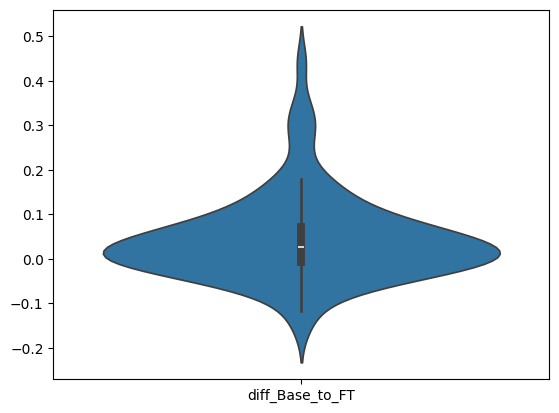

In [45]:
sns.violinplot(data=merged_df[['diff_Base_to_FT']])

In [172]:
merged_df['canto_char_ratio'].quantile([0.1, 0.25, 0.5, 0.75, 0.9])

0.10    0.043666
0.25    0.062459
0.50    0.095238
0.75    0.123810
0.90    0.174194
Name: canto_char_ratio, dtype: float64

/tmp/ipykernel_171879/1864043688.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  list(map(lambda x: x.set_xticklabels(xtick_labels), axs))
/tmp/ipykernel_171879/1864043688.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  list(map(lambda x: x.set_xticklabels(xtick_labels), axs))
/tmp/ipykernel_171879/1864043688.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  list(map(lambda x: x.set_xticklabels(xtick_labels), axs))
/tmp/ipykernel_171879/1864043688.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  list(map(lambda x: x.set_xticklabels(xtick_labels), axs))


[Text(0.5, 0, 'bins'),
 Text(0.5, 0, 'bins'),
 Text(0.5, 0, 'bins'),
 Text(0.5, 0, 'bins')]

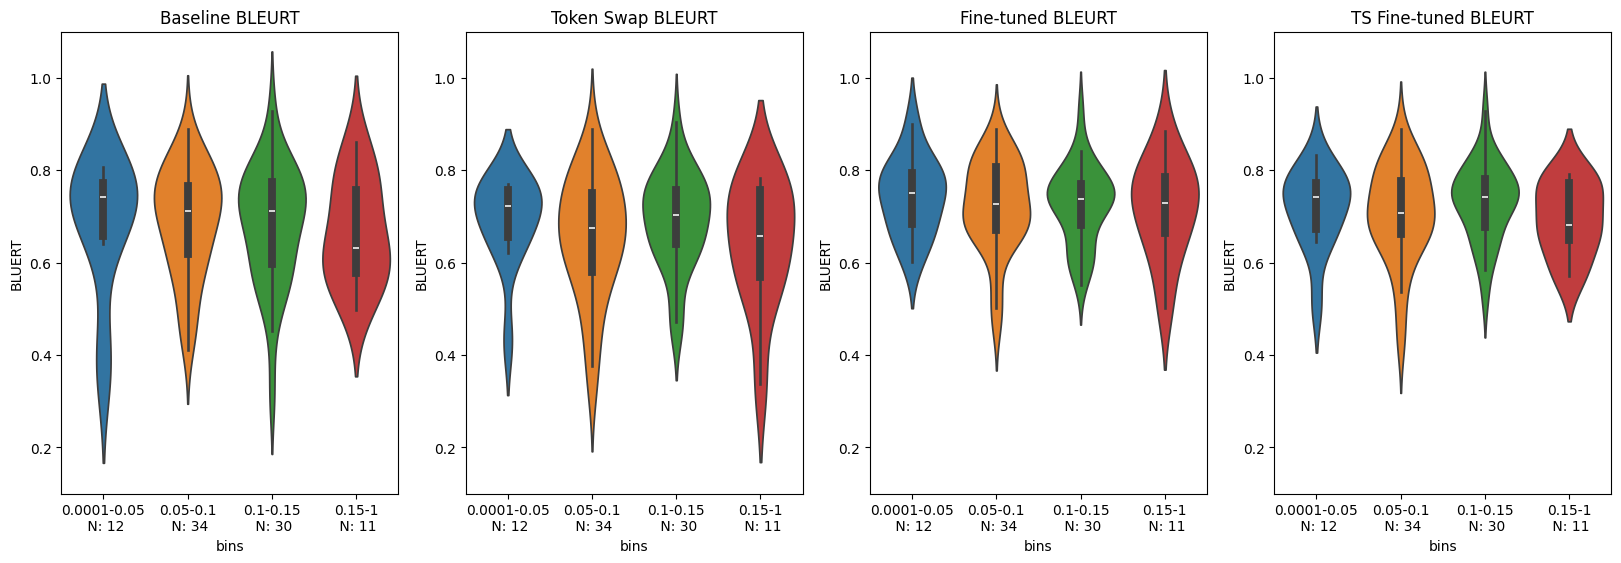

In [197]:
fig, axs = plt.subplots(1, 4,figsize=(20,6))

bins = [0]

bin_ranges = [0.0001, 0.05, 0.1, 0.15, 1]


bins = [np.argwhere((merged_df['canto_char_ratio'] >= bin_ranges[i]) & (merged_df['canto_char_ratio'] < bin_ranges[i+1]) ) for i in range(len(bin_ranges) - 1)]

sns.violinplot([np.array(merged_df['Baseline_BLEURT'])[bin].flatten() for bin in bins], ax=axs[0])
axs[0].set_title('Baseline BLEURT')
sns.violinplot([np.array(merged_df['Token Swap_BLEURT'])[bin].flatten() for bin in bins], ax=axs[1])
axs[1].set_title('Token Swap BLEURT')
sns.violinplot([np.array(merged_df['Fine-tuned_BLEURT'])[bin].flatten() for bin in bins], ax=axs[2])
axs[2].set_title('Fine-tuned BLEURT')
sns.violinplot([np.array(merged_df['TS Fine-tuned_BLEURT'])[bin].flatten() for bin in bins], ax=axs[3])
axs[3].set_title('TS Fine-tuned BLEURT')
xtick_labels = [f"{bin_ranges[i]}-{bin_ranges[i+1]}\n N: {merged_df[ (merged_df['canto_char_ratio'] >= bin_ranges[i]) & (merged_df['canto_char_ratio'] < bin_ranges[i+1]) ].shape[0]}" for i in range(len(bin_ranges)-1)]
#xtick_labels[0] = "0-0.05
list(map(lambda x: x.set_ylim(0.1, 1.1), axs))
list(map(lambda x: x.set_xticklabels(xtick_labels), axs))
list(map(lambda x: x.set_ylabel("BLUERT"), axs))
list(map(lambda x: x.set_xlabel("bins"), axs))

In [175]:
merged_df[(merged_df['canto_only_chars'] < 5)][['src', 'Baseline', 'Token Swap', 'diff_Base_to_TS', 'canto_only_chars']]

,src,Baseline,Token Swap,diff_Base_to_TS,canto_only_chars
2,"Adaptability - flexible, agile mindset, optimistic approach;","Adaptability - flexibility and agility of thinking, positive optimism;","Adaptability - resilience and flexibility of mind, positive optimism;",-0.091260,3
10,"Buddha, in one of his famous quotes, pointed out that the origin of suffering is precisely attachment.",One of the famous introductory words of the Buddha states that the root cause of suffering is attachment.,One of the Buddha’s famous introductions states that the root cause of suffering is attachment.,-0.009781,4
22,"From the smallest to the greatest decisions, choices, and actions.","Decisions, choices and actions from the smallest to the largest.","Decisions, choices and movements from the smallest to the largest.",-0.018096,3
24,"Happy Easter kindergarten decoration concept - rabbit, chicken, egg, bee made from toilet paper roll tube.","Happy Easter kindergarten decoration concept - Bunny, chicken, egg, bee with toilet paper drum.","Happy Easter kindergarten decoration concept - Bunny, chicken, egg, bee with toilet paper.",-0.058332,3
25,"Hey guys, sorry for not writing the report, I didn't get home until now after the practice.","I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry...","Hey, guys, I'm sorry I didn't write that report, I've been practicing until I get home.",0.226302,3
37,"Jesus is our heaven-sent, born-in-a-stable prophet, priest, and king.","Jesus is our prophet, priest and king, who came down from heaven, born in the fold of the horses.","Jesus is the prophet, priest and king who came down from heaven, born in a manger.",0.055269,4
42,"No robot can express sincere empathy, sympathy, compassion, and confidence.","No robot can express genuine empathy, compassion, compassion and self-confidence.","No robot can express genuine and rational compassion, and emotional compassion, and self-confidence.",-0.079199,3
44,Our customer support staff is ready to handle your issue immediately.,Our customer support team is always ready to deal with your questions.,Our customer support team is always ready to deal with your questions.,0.000000,4
50,"Rita delighted in the fresh grapes, although she looked more like she had swallowed a watermelon.","He is happy to stay with the freshly-cuts, but he looks more like a watermelon when he falls.","He is happy to live with the fresh watermelon, but he looks more like he swallowed the watermelon.",0.084741,1
55,"Some of these unkind words include retarded, idiot, stupid and dumb.","Some of the unfriendly words included mentally ill, idiot, fool, and fool.","Some of the unfriendly words included mentally ill, idiot, fool, and fool.",0.000000,4


In [ ]:
import wandb
api = wandb.Api()
run = api.run("/andreashhhansen-aarhus-university/huggingface/runs/t6b9m1rj")


In [37]:
print(type(run.history()['eval/loss'][0]))

<class 'numpy.float64'>


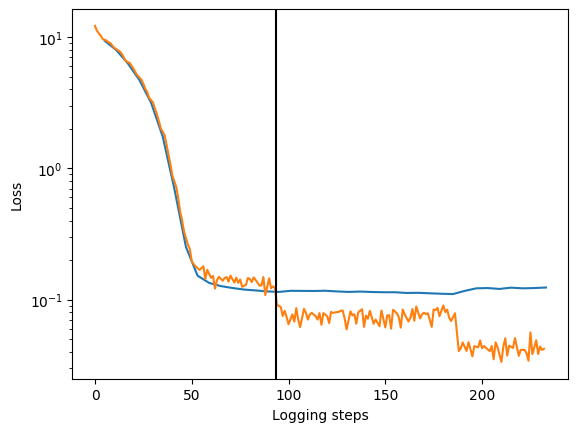

In [57]:
fig, ax = plt.subplots()
ax.plot(run.history()[np.isnan(run.history()['eval/loss']) != True]['eval/loss'])
ax.plot(run.history()[np.isnan(run.history()['train/loss']) != True]['train/loss'])
ax.set_yscale('log')
ax.set_xlabel('Logging steps')
ax.set_ylabel('Loss')
plt.axvline(x=78+78/5, color='black')
plt.savefig('report/data_and_figs/finetuning_training_loss_plot.pdf')

In [2]:
datasets: dict = {}  # Dictionary to hold per-model DataFrames

baseline_file =   ('evaluation_translations/smolsent_whole__translations_original_madlad.json')  # Fine-tuned model file path
token_swap_file = ('evaluation_translations/smolsent_whole_tokenswap_translations_original_madlad.json')  # Fine-tuned token replacement file path
file_paths = {
    'Baseline': baseline_file,
    'Token Swap': token_swap_file,
}


# Read each file and keep only src, trg and the model's translation as a column named by the label
translation_key = 'madlad_translation'
for label, file_path in file_paths.items():
    with open(file_path, 'r') as f:
        data = json.load(f)
        df = pd.DataFrame(data)
        # find translation column (fallback to any column containing 'trans')
        trans_col = translation_key if translation_key in df.columns else next((c for c in df.columns if 'trans' in c.lower()), None)
        if trans_col is None:
            raise KeyError(f"No translation column found in {file_path}")
        df = df[['src', 'trg', trans_col]].rename(columns={trans_col: label})
        trg_label = 'trg' if 'swap' not in file_path.lower() else 'trg_swapped'
        df: pd.DataFrame = df.rename(columns={'trg': trg_label})
        print(df.columns)
        datasets[label] = df

# Merge all model DataFrames on src and trg so each row has translations from every model
from functools import reduce
whole_df = pd.merge(datasets['Baseline'], datasets['Token Swap'], on=['src'], how='outer')
# Remove duplicate source sentences (if any) and reset index
whole_df = whole_df.drop_duplicates(subset=['src']).reset_index(drop=True)
# Display the first few rows of the merged (wide) DataFrame
whole_df.head()

Index(['src', 'trg', 'Baseline'], dtype='object')
Index(['src', 'trg_swapped', 'Token Swap'], dtype='object')


,src,trg,Baseline,trg_swapped,Token Swap
0,A warehouse worker in a retail store is holdin...,間零售店嘅倉務員拎住部手機，同埋準備打包個包裹寄去海外。,The storekeeper in the retail store takes the ...,間零售店的倉務員拎居住部手機，和埋準備打包那个包裹寄去海外。,The warehouseman at the retail store took the ...
1,"Accent your yard with timber for pure privacy,...",用木材嚟提升你個後院，可以純粹增加啲私隱度，當一個舒適嘅乘涼地方，或者比個地方你啲仔女玩鞦韆。,Using wood to enhance your backyard can simply...,用木材嚟提升你那个後院，可以純粹增加啲隐私度，当一那个舒適的乘涼地方，或者比那个地方你啲仔女...,Upgrading your backyard with wood can simply a...
2,Accessories lend visual appeal through pattern...,配飾通過圖案同質感令視覺外觀更吸引。,The decorations are made more attractive by th...,配飾通过图案和質感令视觉外觀更吸引。,Decoration makes the visual appearance more at...
3,"According to the initial findings, Bilici died...",根據初步調查，比利斯係死於心臟病發作。,"According to preliminary investigations, Billy...",根据初步调查，比利斯是死於心脏病發作。,"According to preliminary investigations, Billy..."
4,Acute inflammation (meaning it doesn’t last lo...,急性發炎 (即係唔會持續好耐) 有助身體對抗感染同促進癒合。,"Acute inflammation (i.e., not persistent) help...",急性发炎 (即是不会持续好耐) 有助身体对抗感染和促进癒合。,"Acute inflammation (that is, not persistent) h..."


In [3]:
with open('smoldata/smol_data_split.json', 'r') as f:
    smolsent_data = json.load(f)

print(smolsent_data['smol_validation']['src'])
smolsent_validation_srcs = [item for item in smolsent_data['smol_validation']['src']]
validation_df = whole_df[whole_df['src'].isin(smolsent_validation_srcs)]

['Here, too, males’ education outcomes improved significantly.', 'When we are obedient, faithful and fervent in spirit, and honest, miracles will happen every time we pray to God.', 'Surname searches help you find ancestor charts, family group sheets, and manuscripts in our archive.', 'YouTube also gives brands the possibility to customize how their channel looks.', 'Did your high school play an important role in helping you choose your further education and future career?', 'To accomplish such a great task against long odds will require a highly diverse and efficient organization.', 'Just talking about policies, candidates, and election dates with family and friends is productive.', 'The spinach export price continues to indicate a relatively flat trend pattern.', 'nope i am not a simp', 'Turn visitors into subscribers, paying fans, and lifelong readers.', 'After organizing the exam, the commission also conducts an interview session to recruit capable applicants for the declared posts

In [21]:
for col in tqdm.tqdm(['Baseline', 'Token Swap']):
    print(f"Scoring column: {col}")
    references = (validation_df['src'].tolist())
    candidates = validation_df[col].tolist()
    print(references[0])
    scores = scorer.score(references=references, candidates=candidates)
    validation_df[f'{col}_BLEURT'] = scores


  0%|          | 0/2 [00:00<?, ?it/s]

Scoring column: Baseline
Adding another hurdle, Chinese banks and tech giants control distribution channels.


/tmp/ipykernel_44881/2298470520.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  validation_df[f'{col}_BLEURT'] = scores
 50%|█████     | 1/2 [03:32<03:32, 212.68s/it]

Scoring column: Token Swap
Adding another hurdle, Chinese banks and tech giants control distribution channels.


/tmp/ipykernel_44881/2298470520.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  validation_df[f'{col}_BLEURT'] = scores
100%|██████████| 2/2 [07:05<00:00, 212.51s/it]


In [22]:
print(np.mean(validation_df['Baseline_BLEURT']))
print(np.mean(validation_df['Token Swap_BLEURT']))

0.6887803964916317
0.6704200304102623


In [25]:
with open("yue_zh.jsonl") as f:
    yue_zh_characters_validation = pd.read_json(f, lines=True)
with open("unlabelled/character_classification.json", "r") as f:
    character_classfication = json.load(f)

characters = yue_zh_characters_validation.sort_values(by="src", key=lambda x:x.str.len(), ascending=False)  # type: ignore
def swap_tokens_with_count(sentence: str) -> tuple[str, int]:
    result = ""
    swapped_count = 0
    i = 0
    while i < len(sentence):
        found = False
        for k in range(len(characters)):
            if characters["src"][k] == sentence[i:i+len(characters["src"][k] )]:
                result = result + characters["trgs"][k][0].split(";")[0]
                
                # only count the swaps that actually make a change
                if characters["trgs"][k][0].split(";")[0] != sentence[i:i+len(characters["src"][k])]: 
                    swapped_count += len(characters["trgs"][k][0].split(";")[0])
                    
                i += len(characters["src"][k])
                found = True
                break
        if not found:
            result += sentence[i]
            i += 1
    
    return result, swapped_count

In [39]:
validation_df['canto_only_chars'] = validation_df['trg'].apply(lambda x: swap_tokens_with_count(x)[1])
validation_df['total_chars'] = validation_df['trg'].str.len()
validation_df['canto_char_ratio'] = validation_df['canto_only_chars'] / validation_df['total_chars']

/tmp/ipykernel_44881/439893355.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  validation_df['canto_only_chars'] = validation_df['trg'].apply(lambda x: swap_tokens_with_count(x)[1])
/tmp/ipykernel_44881/439893355.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  validation_df['total_chars'] = validation_df['trg'].str.len()
/tmp/ipykernel_44881/439893355.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inst

In [ ]:
#load from csv
validation_df = pd.read_csv('evaluation_translations/smolsent_validation_bleurt_scores_madlad.csv')
validation_df['canto_only_chars'].quantile([0.25, 0.5, 0.75])

0.25     5.0
0.50     9.0
0.75    12.0
Name: canto_only_chars, dtype: float64

/tmp/ipykernel_10750/1703388688.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels)


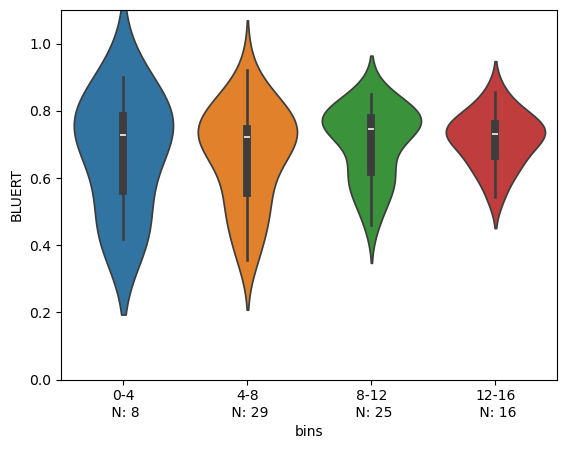

In [9]:
bin_ranges = [0, 4, 8, 12, 16]
bins = [np.argwhere((validation_df['canto_only_chars'] >= bin_ranges[i]) & (validation_df['canto_only_chars'] < bin_ranges[i+1]) ) for i in range(len(bin_ranges) - 1)]

figure, ax = plt.subplots()

sns.violinplot([np.array(validation_df['Baseline_BLEURT'])[bin].flatten() for bin in bins])
xtick_labels = [f"{bin_ranges[i]}-{bin_ranges[i+1]}\n N: {len(validation_df[(validation_df['canto_only_chars'] >= bin_ranges[i]) & (validation_df['canto_only_chars'] < bin_ranges[i+1])])}" for i in range(len(bin_ranges)-1)]
#xtick_labels[0] = "0-0.05
ax.set_ylim(0, 1.1)
ax.set_xticklabels(xtick_labels)
ax.set_ylabel("BLUERT")
ax.set_xlabel("bins")
plt.savefig("report/data_and_figs/violin_baseline_validation.pdf")

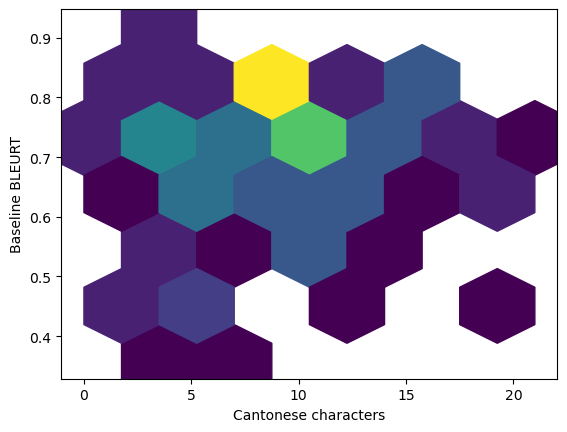

In [15]:
hexbin_size = 6


fig, ax = plt.subplots()
ax.hexbin(
    validation_df['canto_only_chars'].to_numpy(),
    validation_df['Baseline_BLEURT'].to_numpy(),
    gridsize=hexbin_size,
    #cmap="ciridis", 
    mincnt=1
    )
ax.set_xlabel("Cantonese characters")
ax.set_ylabel("Baseline BLEURT")
fig.savefig("report/data_and_figs/hexbin_baseline_validation.pdf")

In [94]:
validation_df.to_csv('evaluation_translations/smolsent_validation_bleurt_scores_madlad.csv', index=False)